# 19 Figure style test

Purpose:
Test a unified plotting style for the hydrovoltaic ML manuscript.

This notebook uses Figure 4A and Figure 4B as style-test examples.

Color logic:
- low-R regime: green
- high-R regime: vermillion
- raw data: gray
- statistical trend: black

Outputs:
- PDF for Adobe Illustrator workflow
- EPS as backup
- PNG for quick preview

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

print("Matplotlib version:", mpl.__version__)
print("Working directory:", Path.cwd())

Matplotlib version: 3.10.9
Working directory: c:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\notebooks


In [2]:
%%writefile paper_style.py
# paper_style.py
# Shared plotting style for the hydrovoltaic ML manuscript

from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt


# Main palette
COLORS = {
    "black": "#000000",
    "dark_gray": "#4D4D4D",
    "gray": "#8C8C8C",
    "light_gray": "#C7C7C7",
    "very_light_gray": "#EFEFEF",

    # Your preferred publication palette
    "vermillion": "#D55E00",
    "orange": "#E69F00",
    "green": "#009E73",
    "sky_blue": "#56B4E9",
    "blue": "#0072B2",
    "purple": "#CC79A7",
    "yellow": "#F0E442",
}

# Semantic colors for this paper
SEMANTIC = {
    # Main regime colors
    "favorable": "#009E73",      # low-R point color
    "limited": "#D55E00",        # high-R point color

    # Soft fill colors used consistently for regime background and box fill
    "favorable_fill": "#BFD8CF", # soft green fill
    "limited_fill": "#E7D3BE",   # soft warm fill

    # Neutral colors
    "raw_data": "#BDBDBD",
    "trend": "#000000",
    "reference": "#D0D0D0",
}

FIG_SIZES = {
    "single": (3.35, 2.65),
    "wide": (6.8, 2.8),
    "two_panel": (6.8, 2.8),
    "four_panel": (7.2, 5.6),
    "square": (3.2, 3.2),
}


def set_paper_style(context="panel"):
    """
    Set matplotlib style for manuscript figures.
    """
    if context == "panel":
        base_font = 8.5
        label_font = 9.5
        title_font = 10.0
        legend_font = 8.0
    elif context == "combined":
        base_font = 9.0
        label_font = 10.0
        title_font = 10.5
        legend_font = 8.5
    else:
        raise ValueError("context must be 'panel' or 'combined'")

    mpl.rcParams.update({
        "font.family": "Arial",
        "font.size": base_font,
        "font.weight": "normal",

        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",

        "axes.linewidth": 1.0,
        "axes.labelsize": label_font,
        "axes.titlesize": title_font,
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "xtick.labelsize": base_font,
        "ytick.labelsize": base_font,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,

        "lines.linewidth": 1.2,
        "lines.markersize": 4,

        "legend.fontsize": legend_font,
        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.borderaxespad": 0.4,

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
        "savefig.dpi": 600,

        "figure.dpi": 150,
        "axes.grid": False,
    })


def format_ax(ax, mirror=True, top_right_ticks=False):
    """
    Consistent axis styling.
    """
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color(COLORS["black"])

    if mirror:
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)
    else:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    ax.tick_params(
        direction="out",
        width=1.0,
        length=4,
        color=COLORS["black"],
        top=top_right_ticks,
        right=top_right_ticks
    )
    ax.tick_params(which="minor", direction="out", width=0.8, length=2)
    return ax


def add_zero_line(ax, axis="y"):
    """
    Add light dashed zero/reference line.
    """
    if axis == "y":
        ax.axhline(0, color=SEMANTIC["reference"], linestyle="--", linewidth=1.0, zorder=0)
    elif axis == "x":
        ax.axvline(0, color=SEMANTIC["reference"], linestyle="--", linewidth=1.0, zorder=0)
    else:
        raise ValueError("axis must be 'x' or 'y'")


def add_vertical_threshold(ax, x, label=None, color="#AFAFAF"):
    """
    Add vertical threshold line, e.g., log(R) = -1.
    """
    ax.axvline(x, color=color, linestyle="--", linewidth=1.0, zorder=0)
    if label is not None:
        ymin, ymax = ax.get_ylim()
        ax.text(
            x, ymax - 0.05*(ymax - ymin), label,
            ha="left", va="top",
            fontsize=8, color=color
        )


def shade_regimes(ax, threshold=-1.0,
                  low_color="#009E73", high_color="#D55E00",
                  alpha=0.06):
    """
    Add subtle background shading for low-R and high-R regimes.
    """
    xmin, xmax = ax.get_xlim()
    ax.axvspan(xmin, threshold, color=low_color, alpha=alpha, lw=0, zorder=0)
    ax.axvspan(threshold, xmax, color=high_color, alpha=alpha, lw=0, zorder=0)


def add_panel_label(ax, label, x=-0.16, y=1.12, fontsize=13):
    """
    Add panel label such as A, B, C, D.
    """
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold",
        color=COLORS["black"]
    )


def save_figure(fig, out_dir, name, formats=("pdf", "eps", "png")):
    """
    Save figure in multiple formats.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    saved = []
    for fmt in formats:
        path = out_dir / f"{name}.{fmt}"
        if fmt == "png":
            fig.savefig(path, dpi=600, bbox_inches="tight")
        else:
            fig.savefig(path, bbox_inches="tight")
        saved.append(path)

    return saved

Writing paper_style.py


In [3]:
from paper_style import (
    COLORS,
    SEMANTIC,
    FIG_SIZES,
    set_paper_style,
    format_ax,
    add_zero_line,
    add_vertical_threshold,
    shade_regimes,
    add_panel_label,
    save_figure,
)

set_paper_style(context="panel")

In [4]:
ROOT = Path("..")
RESULTS_DIR = ROOT / "results"
OUT_DIR = RESULTS_DIR / "figure_style_test"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output folder:", OUT_DIR.resolve())

Output folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure_style_test


In [5]:
candidate_files = [
    Path("hydrovoltaic_dataset_phase2_input_utf8.csv"),
    ROOT / "notebooks" / "hydrovoltaic_dataset_phase2_input_utf8.csv",
    ROOT / "data" / "processed" / "hydrovoltaic_dataset_phase2_input_utf8.csv",
]

DATA_FILE = None
for p in candidate_files:
    if p.exists():
        DATA_FILE = p
        break

if DATA_FILE is None:
    raise FileNotFoundError("Could not find hydrovoltaic_dataset_phase2_input_utf8.csv")

df = pd.read_csv(DATA_FILE, encoding="utf-8-sig")

print("Loaded:", DATA_FILE)
print("Shape:", df.shape)
display(df.head())

Loaded: hydrovoltaic_dataset_phase2_input_utf8.csv
Shape: (159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,...,ion_type,asym_env,asym_chem,asym_electrode,mechanism_simple,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,1,0,0,streaming,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,...,anion,1,0,0,streaming,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,...,anion,1,1,0,streaming,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,1,0,0,streaming,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,1,0,0,streaming,1,0,0,NaN,0


In [6]:
R_COL = "log_internal_resistance_Mohm"
TARGET_COL = "log_estimated_power_density"

required_cols = [R_COL, TARGET_COL]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_r = df.dropna(subset=[R_COL, TARGET_COL]).copy()
df_r[R_COL] = pd.to_numeric(df_r[R_COL], errors="coerce")
df_r[TARGET_COL] = pd.to_numeric(df_r[TARGET_COL], errors="coerce")
df_r = df_r.dropna(subset=[R_COL, TARGET_COL]).copy()

R_THRESHOLD = -1.0

df_r["R_regime"] = np.where(
    df_r[R_COL] <= R_THRESHOLD,
    "low_R",
    "high_R"
)

print("Observed-R subset:", df_r.shape)
display(df_r["R_regime"].value_counts())

Observed-R subset: (112, 53)


R_regime
high_R    57
low_R     55
Name: count, dtype: int64

In [7]:
def make_binned_summary(data, x_col, y_col, n_bins=5):
    d = data[[x_col, y_col]].dropna().copy()
    d["bin"] = pd.cut(d[x_col], bins=n_bins)

    summary = (
        d.groupby("bin", observed=True)
        .agg(
            x_mean=(x_col, "mean"),
            y_mean=(y_col, "mean"),
            y_sem=(y_col, lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0),
            n=(y_col, "count"),
        )
        .reset_index()
    )
    return summary

binned = make_binned_summary(df_r, R_COL, TARGET_COL, n_bins=5)
display(binned)

,bin,x_mean,y_mean,y_sem,n
0,"(-3.475, -2.175]",-2.675743,0.540706,0.267709,14
1,"(-2.175, -0.881]",-1.482433,0.323971,0.155637,43
2,"(-0.881, 0.413]",-0.058054,-0.764426,0.174605,35
3,"(0.413, 1.706]",1.076254,-0.763875,0.409733,15
4,"(1.706, 3.0]",2.388024,-1.799478,0.468756,5


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved:
..\results\figure_style_test\style_test_fig4A_internal_resistance_vs_performance.pdf
..\results\figure_style_test\style_test_fig4A_internal_resistance_vs_performance.eps
..\results\figure_style_test\style_test_fig4A_internal_resistance_vs_performance.png


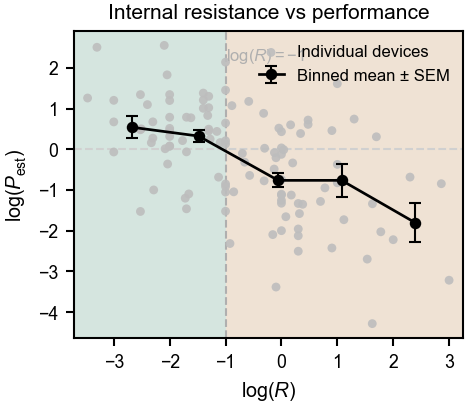

In [8]:
fig, ax = plt.subplots(figsize=FIG_SIZES["single"])

# Set x-limits first so regime shading covers the full panel
x_pad = 0.25
xmin = df_r[R_COL].min() - x_pad
xmax = df_r[R_COL].max() + x_pad
ax.set_xlim(xmin, xmax)

# Subtle regime shading
shade_regimes(
    ax,
    threshold=R_THRESHOLD,
    low_color=SEMANTIC["favorable_fill"],
    high_color=SEMANTIC["limited_fill"],
    alpha=0.65
)

# Raw data
ax.scatter(
    df_r[R_COL],
    df_r[TARGET_COL],
    s=18,
    color=SEMANTIC["raw_data"],
    alpha=0.9,
    edgecolor="none",
    label="Individual devices",
    zorder=1,
)

# Binned trend
ax.errorbar(
    binned["x_mean"],
    binned["y_mean"],
    yerr=binned["y_sem"],
    fmt="o-",
    color=SEMANTIC["trend"],
    ecolor=SEMANTIC["trend"],
    elinewidth=1.0,
    capsize=3,
    markersize=4.5,
    markerfacecolor=SEMANTIC["trend"],
    markeredgecolor=SEMANTIC["trend"],
    linewidth=1.3,
    label="Binned mean ± SEM",
    zorder=3,
)

add_zero_line(ax, axis="y")
add_vertical_threshold(ax, R_THRESHOLD, label=r"$\log(R)=-1$")

ax.set_xlabel(r"$\log(R)$")
ax.set_ylabel(r"$\log(P_{\mathrm{est}})$")
ax.set_title("Internal resistance vs performance")

format_ax(ax, mirror=True, top_right_ticks=False)
ax.legend(loc="upper right", frameon=False)

saved = save_figure(fig, OUT_DIR, "style_test_fig4A_internal_resistance_vs_performance")
print("Saved:")
for p in saved:
    print(p)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved:
..\results\figure_style_test\style_test_fig4B_performance_by_resistance_regime.pdf
..\results\figure_style_test\style_test_fig4B_performance_by_resistance_regime.eps
..\results\figure_style_test\style_test_fig4B_performance_by_resistance_regime.png


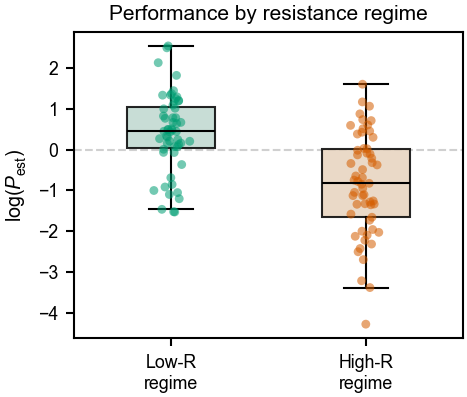

In [9]:
fig, ax = plt.subplots(figsize=FIG_SIZES["single"])

order = ["low_R", "high_R"]
labels = ["Low-R\nregime", "High-R\nregime"]
positions = np.arange(1, len(order) + 1)

data_groups = [
    df_r.loc[df_r["R_regime"] == group, TARGET_COL].dropna().values
    for group in order
]

box_fill_colors = [SEMANTIC["favorable_fill"], SEMANTIC["limited_fill"]]
point_colors = [SEMANTIC["favorable"], SEMANTIC["limited"]]

bp = ax.boxplot(
    data_groups,
    positions=positions,
    widths=0.45,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color=COLORS["black"], linewidth=1.0),
    boxprops=dict(linewidth=1.0, color=COLORS["black"]),
    whiskerprops=dict(linewidth=1.0, color=COLORS["black"]),
    capprops=dict(linewidth=1.0, color=COLORS["black"]),
)

for patch, color in zip(bp["boxes"], box_fill_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor(COLORS["black"])

# Jittered raw data
rng = np.random.default_rng(42)

for i, group in enumerate(order, start=1):
    y = df_r.loc[df_r["R_regime"] == group, TARGET_COL].dropna().values
    x = rng.normal(loc=i, scale=0.045, size=len(y))

    ax.scatter(
        x,
        y,
        s=18,
        color=point_colors[i - 1],
        alpha=0.55,
        edgecolor="none",
        zorder=2,
    )

add_zero_line(ax, axis="y")

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel(r"$\log(P_{\mathrm{est}})$")
ax.set_title("Performance by resistance regime")

format_ax(ax, mirror=True, top_right_ticks=False)

saved = save_figure(fig, OUT_DIR, "style_test_fig4B_performance_by_resistance_regime")
print("Saved:")
for p in saved:
    print(p)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved:
..\results\figure_style_test\style_test_fig4AB_combined_preview.pdf
..\results\figure_style_test\style_test_fig4AB_combined_preview.eps
..\results\figure_style_test\style_test_fig4AB_combined_preview.png


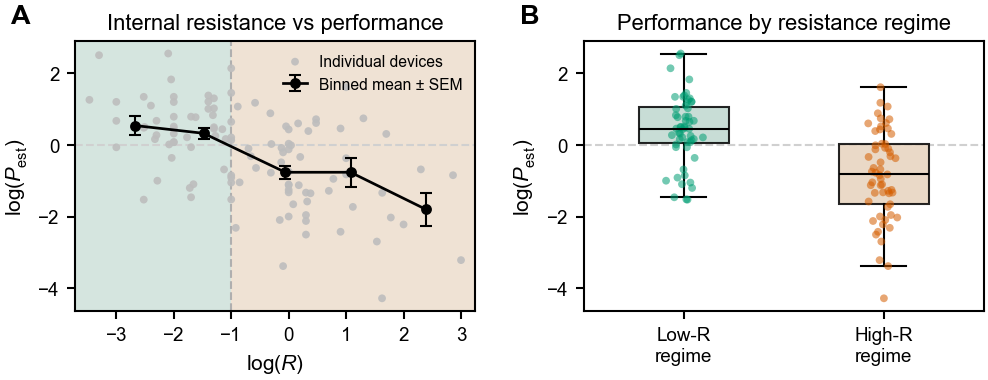

In [10]:
set_paper_style(context="combined")

fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.8))

# -------------------------
# Panel A
# -------------------------
ax = axes[0]

x_pad = 0.25
xmin = df_r[R_COL].min() - x_pad
xmax = df_r[R_COL].max() + x_pad
ax.set_xlim(xmin, xmax)

shade_regimes(
    ax,
    threshold=R_THRESHOLD,
    low_color=SEMANTIC["favorable_fill"],
    high_color=SEMANTIC["limited_fill"],
    alpha=0.65
)

ax.scatter(
    df_r[R_COL],
    df_r[TARGET_COL],
    s=14,
    color=SEMANTIC["raw_data"],
    alpha=0.9,
    edgecolor="none",
    label="Individual devices",
    zorder=1,
)

ax.errorbar(
    binned["x_mean"],
    binned["y_mean"],
    yerr=binned["y_sem"],
    fmt="o-",
    color=SEMANTIC["trend"],
    ecolor=SEMANTIC["trend"],
    elinewidth=1.0,
    capsize=3,
    markersize=4.2,
    markerfacecolor=SEMANTIC["trend"],
    markeredgecolor=SEMANTIC["trend"],
    linewidth=1.3,
    label="Binned mean ± SEM",
    zorder=3,
)

add_zero_line(ax, axis="y")
add_vertical_threshold(ax, R_THRESHOLD)

ax.set_xlabel(r"$\log(R)$")
ax.set_ylabel(r"$\log(P_{\mathrm{est}})$")
ax.set_title("Internal resistance vs performance")
format_ax(ax, mirror=True, top_right_ticks=False)
add_panel_label(ax, "A", x=-0.16, y=1.14, fontsize=13)
ax.legend(loc="upper right", frameon=False, fontsize=7.5)

# -------------------------
# Panel B
# -------------------------
ax = axes[1]

bp = ax.boxplot(
    data_groups,
    positions=positions,
    widths=0.45,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color=COLORS["black"], linewidth=1.0),
    boxprops=dict(linewidth=1.0, color=COLORS["black"]),
    whiskerprops=dict(linewidth=1.0, color=COLORS["black"]),
    capprops=dict(linewidth=1.0, color=COLORS["black"]),
)

for patch, color in zip(bp["boxes"], box_fill_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor(COLORS["black"])

rng = np.random.default_rng(42)

for i, group in enumerate(order, start=1):
    y = df_r.loc[df_r["R_regime"] == group, TARGET_COL].dropna().values
    x = rng.normal(loc=i, scale=0.045, size=len(y))

    ax.scatter(
        x,
        y,
        s=14,
        color=point_colors[i - 1],
        alpha=0.55,
        edgecolor="none",
        zorder=2,
    )

add_zero_line(ax, axis="y")
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel(r"$\log(P_{\mathrm{est}})$")
ax.set_title("Performance by resistance regime")
format_ax(ax, mirror=True, top_right_ticks=False)
add_panel_label(ax, "B", x=-0.16, y=1.14, fontsize=13)

plt.tight_layout(w_pad=2.0)

saved = save_figure(
    fig,
    OUT_DIR,
    "style_test_fig4AB_combined_preview",
    formats=("pdf", "eps", "png")
)

print("Saved:")
for p in saved:
    print(p)

plt.show()

# Reset
set_paper_style(context="panel")

In [11]:
print("Generated files:")
for p in sorted(OUT_DIR.glob("*")):
    print(p.name)

Generated files:
style_test_fig4A_internal_resistance_vs_performance.eps
style_test_fig4A_internal_resistance_vs_performance.pdf
style_test_fig4A_internal_resistance_vs_performance.png
style_test_fig4AB_combined_preview.eps
style_test_fig4AB_combined_preview.pdf
style_test_fig4AB_combined_preview.png
style_test_fig4B_performance_by_resistance_regime.eps
style_test_fig4B_performance_by_resistance_regime.pdf
style_test_fig4B_performance_by_resistance_regime.png
